<a href="https://colab.research.google.com/github/thaiantl-code/hocsau/blob/main/LinearRegression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [31]:
# Linear Regression Project
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

df = pd.read_csv("https://raw.githubusercontent.com/thaiantl-code/hocsau/refs/heads/main/Advertising.csv")
df = df.drop("Unnamed: 0", axis=1)#dataset co cột unmate là cột dữ liệu không phải feature nên xóa đi

df.corr()# xác định tương quan giữa các cột để xác định feature--> chọn TV và radio



,TV,Radio,Newspaper,Sales
TV,1.000000,0.054809,0.056648,0.782224
Radio,0.054809,1.000000,0.354104,0.576223
Newspaper,0.056648,0.354104,1.000000,0.228299
Sales,0.782224,0.576223,0.228299,1.000000


In [30]:
df.head()

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


In [49]:
df.duplicated().sum() # kiem tra co duplicated khong


np.int64(0)

In [51]:
df.isnull().values.any()# kiem tra co missing ko


np.False_

In [15]:
X = df[['TV','Radio']]
y = df['Sales'] # features


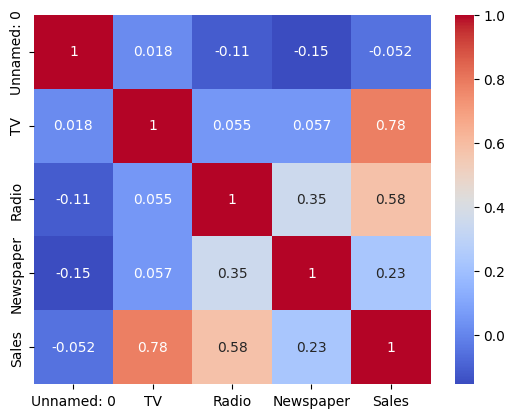

In [16]:
import matplotlib.pyplot as plt

sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.show()


<Axes: xlabel='Sales', ylabel='TV'>

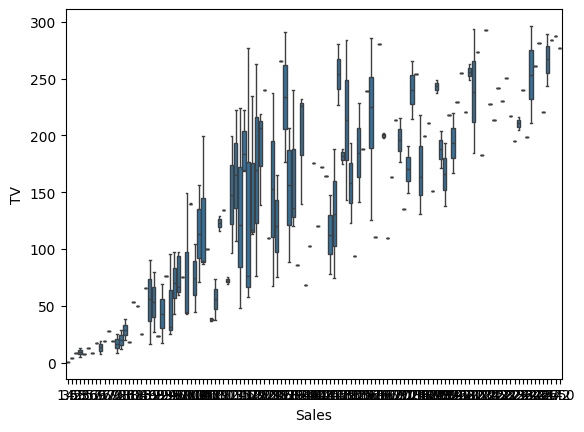

In [39]:
import seaborn as sns
sns.boxplot(y='TV', x='Sales', data = df)

In [40]:
#xac dinh outlier và loai bỏ
Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)

IQR = Q3 - Q1

outliers = df[
    ((df < (Q1 - 1.5 * IQR)) | (df > (Q3 + 1.5 * IQR)))
]

print(outliers)




     TV  Radio  Newspaper  Sales
0   NaN    NaN        NaN    NaN
1   NaN    NaN        NaN    NaN
2   NaN    NaN        NaN    NaN
3   NaN    NaN        NaN    NaN
4   NaN    NaN        NaN    NaN
..   ..    ...        ...    ...
195 NaN    NaN        NaN    NaN
196 NaN    NaN        NaN    NaN
197 NaN    NaN        NaN    NaN
198 NaN    NaN        NaN    NaN
199 NaN    NaN        NaN    NaN

[200 rows x 4 columns]


In [42]:
#loai bo oulier
Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)

IQR = Q3 - Q1

data_clean = df[
    ~((df < (Q1 - 1.5 * IQR)) |
      (df > (Q3 + 1.5 * IQR))).any(axis=1)
]


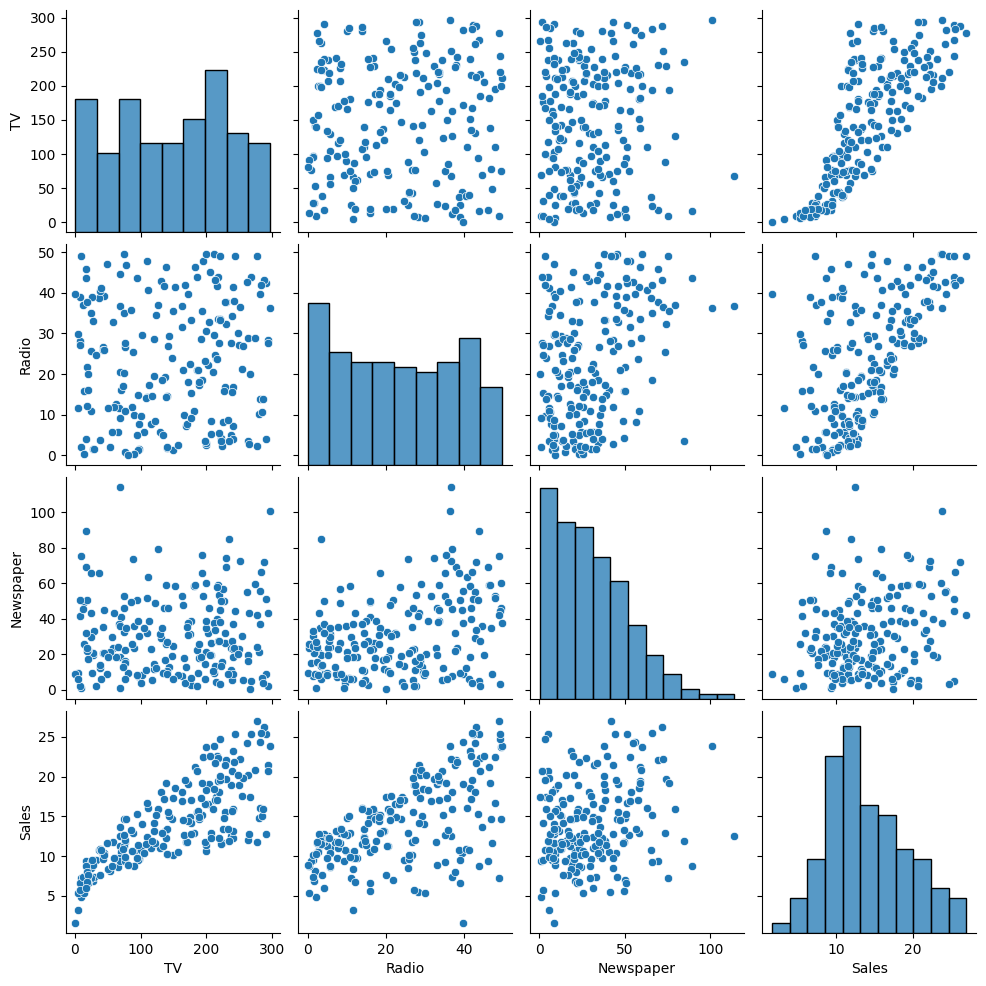

In [43]:
sns.pairplot(df)


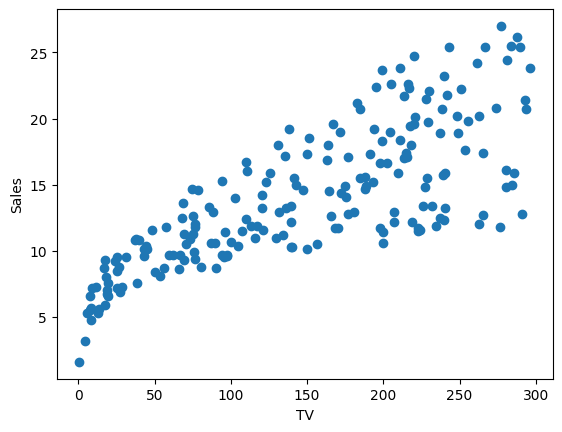

In [44]:
import matplotlib.pyplot as plt

plt.scatter(df["TV"], df["Sales"])
plt.xlabel("TV")
plt.ylabel("Sales")
plt.show()

# New Section

In [45]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [46]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [47]:
# TODO: Make predictions
y_pred = model.predict(X_test)

In [48]:
print(y_pred, y_test)

[16.35747252 20.86299397 21.52505848 10.58719845 22.22459614 13.06070499
 21.09564403  7.47641062 13.62409831 15.15019438  9.12761147  6.62878923
 14.16531076  8.97073929  9.66825463 12.12821691  8.71252199 16.30911498
 10.26684186 18.89010391 19.4519532  13.03925601 12.41182149 21.20994137
  7.88771365  5.80255394 20.7764401  12.02358305  9.1784369   8.59012258
 12.46070487 10.03213267 21.34367738 12.11632301 18.23376459 20.22242395
 14.14999367 20.78067544 11.07322103  4.56335118] 95     16.9
15     22.4
30     21.4
158     7.3
128    24.7
115    12.6
69     22.3
170     8.4
174    11.5
45     14.9
66      9.5
182     8.7
165    11.9
78      5.3
186    10.3
177    11.7
56      5.5
152    16.6
82     11.3
68     18.9
124    19.7
16     12.5
148    10.9
93     22.2
65      9.3
60      8.1
84     21.7
67     13.4
125    10.6
132     5.7
9      10.6
18     11.3
55     23.7
75      8.7
150    16.1
104    20.7
135    11.6
137    20.8
164    11.9
76      6.9
Name: Sales, dtype: float64


In [ ]:
# TODO: Prepare features and target
# X = df[['feature1', 'feature2', ...]]
# y = df['target']

# Split data
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# TODO: Train your model
# model = LinearRegression()
# model.fit(X_train, y_train)

# TODO: Make predictions
# y_pred = model.predict(X_test)

# TODO: Evaluate
# mse = mean_squared_error(y_test, y_pred)
# r2 = r2_score(y_test, y_pred)

# print(f'MSE: {mse}')
# print(f'R2 Score: {r2}')

In [24]:
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f'MSE: {mse}')
print(f'R2 Score: {r2}')

MSE: 3.137948009068354
R2 Score: 0.9005833101920356
